# Telco Customer Churn Prediction
Complete ML Project

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


In [22]:
# Load dataset
df = pd.read_csv('Telco_Customer_Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
# Data preprocessing
# Strip whitespace and normalize column names
df.columns = df.columns.str.strip()

if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.dropna(inplace=True)

target_col = next((col for col in df.columns if col.lower() == 'churn'), None)
if target_col is None:
    raise KeyError("Expected target column 'Churn' not found in dataset.")

if target_col != 'Churn':
    df.rename(columns={target_col: 'Churn'}, inplace=True)

# Encode target column
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Separate features and target before encoding categorical features
X = df.drop(columns=['Churn'])
y = df['Churn']

# One-hot encode only feature columns that are still categorical
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Scale numeric features
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


C:\Users\Loq\AppData\Local\Temp\ipykernel_15296\815846246.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [24]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7874911158493249


In [25]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7896233120113717


In [26]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7093105899076049



Logistic Regression
Accuracy: 0.7874911158493249
              precision    recall  f1-score   support

          No     0.8349    0.8858    0.8596      1033
         Yes     0.6206    0.5160    0.5635       374

    accuracy                         0.7875      1407
   macro avg     0.7277    0.7009    0.7115      1407
weighted avg     0.7779    0.7875    0.7809      1407



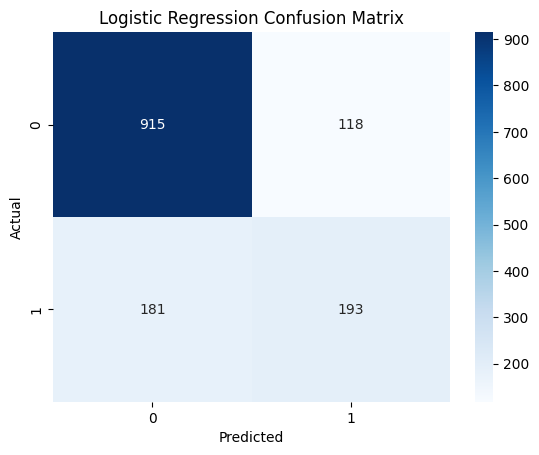


Random Forest
Accuracy: 0.7896233120113717
              precision    recall  f1-score   support

          No     0.8276    0.9013    0.8628      1033
         Yes     0.6383    0.4813    0.5488       374

    accuracy                         0.7896      1407
   macro avg     0.7329    0.6913    0.7058      1407
weighted avg     0.7772    0.7896    0.7794      1407



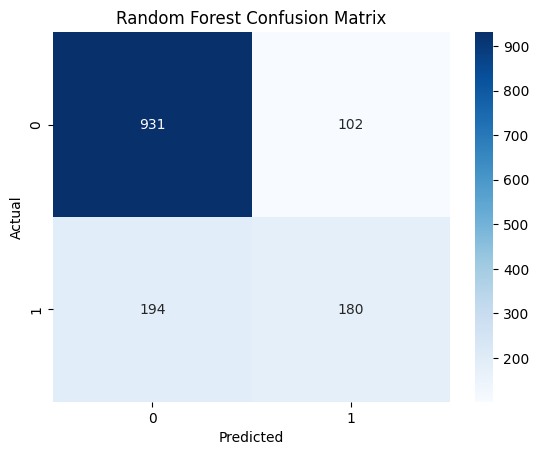


Decision Tree
Accuracy: 0.7093105899076049
              precision    recall  f1-score   support

          No     0.8114    0.7870    0.7990      1033
         Yes     0.4568    0.4947    0.4750       374

    accuracy                         0.7093      1407
   macro avg     0.6341    0.6408    0.6370      1407
weighted avg     0.7171    0.7093    0.7129      1407



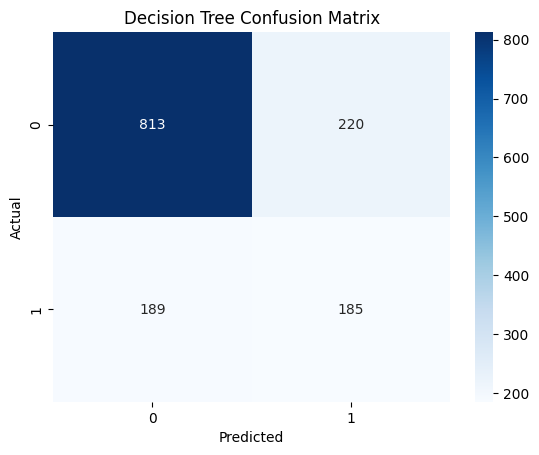

In [27]:
# Model evaluation
model_results = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'Decision Tree': dt_pred,
}

for name, preds in model_results.items():
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds, digits=4))
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [28]:
import joblib
# Save the trained Random Forest model and the scaler
joblib.dump(rf, 'Telco_Customer_Churn.pkl')
joblib.dump(scaler, 'Telco_Customer_Churn_scaler.pkl')

['Telco_Customer_Churn_scaler.pkl']